# Anime Score Forecasting — XGBoost Time Series

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## 1. Load & Aggregate by Season

In [2]:
df_raw = pd.read_csv(r'preprocessed data/feature_engineered_anime_alt.csv').copy()
pd.set_option('display.max_columns', None)
df_raw.head()

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,show_type,status,aired,source,genres,duration_min,episodes,rating,favorites,reviews,favs_rate,desc_length,scored_rate,rec_share,mix_share,not_rec_share,sentiment_balance
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,madhouse,during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,tv,finished airing,"sep 29, 2023 to mar 22, 2024",manga,"adventure, award winning, drama, fantasy",24.0,28.0,pg-13 - teens 13 or older,88070,1079,0.062400,1099,0.616229,0.759036,0.133457,0.107507,0.651529
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,spring 2026,david production,"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,ona,currently airing,"mar 19, 2026 to ?",manga,"action, adventure, mystery, supernatural",47.0,11.0,r - 17+ (violence & profanity),6051,164,0.031859,1194,0.454965,0.951220,0.042683,0.006098,0.945122
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,bones,after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,tv,finished airing,"apr 5, 2009 to jul 4, 2010",manga,"action, adventure, drama, fantasy",24.0,64.0,r - 17+ (violence & profanity),241796,1084,0.065924,1169,0.628020,0.895756,0.063653,0.040590,0.855166
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,fall 2025,mappa,despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,movie,finished airing,"sep 19, 2025",manga,"action, fantasy",99.0,1.0,r - 17+ (violence & profanity),12951,387,0.028830,865,0.628552,0.832041,0.118863,0.049096,0.782946
4,steins;gate,9.07,1516022,14,2802086,spring 2011,white fox,eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,tv,finished airing,"apr 6, 2011 to sep 14, 2011",visual novel,"drama, sci-fi, suspense",24.0,24.0,pg-13 - teens 13 or older,201780,1247,0.072011,1144,0.541033,0.862069,0.070569,0.067362,0.794707


In [3]:
df_raw['year'] = df_raw['season'].str.extract(r'(\d{4})').astype(float)
df_raw['season_name'] = df_raw['season'].str.extract(r'(spring|summer|fall|winter)')

season_order = {'spring': 1, 'summer': 2, 'fall': 3, 'winter': 4}
df_raw['quarter'] = df_raw['season_name'].map(season_order)


df_clean = df_raw.dropna(subset=['year', 'quarter']).copy()
df_clean['year'] = df_clean['year'].astype(int)

In [4]:
agg = df_clean.groupby(['year', 'quarter']).agg(
    avg_score          = ('score',            'mean'),
    avg_members        = ('members',          'mean'),
    avg_favorites      = ('favorites',        'mean'),
    avg_sentiment      = ('sentiment_balance','mean'),
    avg_episodes       = ('episodes',         'mean'),
    avg_duration       = ('duration_min',     'mean'),
    count              = ('title',            'count'),
    manga_share        = ('source',           lambda x: (x == 'manga').mean()),
    original_share     = ('source',           lambda x: (x == 'original').mean()),
    genre_diversity    = ('genres',           lambda x: x.dropna().str.split(', ').explode().nunique()),
).reset_index()

In [5]:
agg

,year,quarter,avg_score,avg_members,avg_favorites,avg_sentiment,avg_episodes,avg_duration,count,manga_share,original_share,genre_diversity
0,1956,2.0,6.470000,1679.000000,2.000000,1.000000,1.000000,16.000000,1,0.000000,1.000000,1
1,1959,1.0,6.140000,2392.000000,4.000000,0.000000,1.000000,16.000000,1,0.000000,1.000000,1
2,1960,2.0,6.200000,4033.000000,9.000000,0.500000,1.000000,88.000000,1,0.000000,0.000000,2
3,1961,2.0,6.330000,3273.000000,5.000000,-0.500000,1.000000,83.000000,1,0.000000,0.000000,1
4,1962,3.0,6.530000,5346.000000,10.000000,0.833333,1.000000,39.000000,1,0.000000,1.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...
248,2025,2.0,7.206296,72564.685185,567.351852,0.326549,13.231481,28.861111,108,0.388889,0.148148,18
249,2025,3.0,7.171461,48909.977528,341.258427,0.346750,11.123596,31.438202,89,0.325843,0.146067,18
250,2025,4.0,7.169059,64688.317647,438.741176,0.311537,12.764706,30.576471,85,0.317647,0.129412,15
251,2026,1.0,7.271270,41970.063492,260.873016,0.088646,11.380952,26.666667,63,0.476190,0.031746,18


In [6]:
agg = agg.sort_values(['year', 'quarter']).reset_index(drop=True)
agg['season_index'] = range(len(agg))

agg = agg[agg['year'] >= 2000].reset_index(drop=True)
agg['season_index'] = range(len(agg))

print(f'Seasons: {len(agg)}')
agg.tail(8)

Seasons: 106


,year,quarter,avg_score,avg_members,avg_favorites,avg_sentiment,avg_episodes,avg_duration,count,manga_share,original_share,genre_diversity,season_index
98,2024,3.0,7.149739,64983.052174,549.782609,0.316096,15.730435,28.504348,115,0.365217,0.113043,16,98
99,2024,4.0,7.146354,93504.260417,824.229167,0.276897,12.864583,27.156250,96,0.312500,0.135417,16,99
100,2025,1.0,7.119785,53871.161290,295.946237,0.275826,10.849462,29.731183,93,0.333333,0.225806,19,100
101,2025,2.0,7.206296,72564.685185,567.351852,0.326549,13.231481,28.861111,108,0.388889,0.148148,18,101
102,2025,3.0,7.171461,48909.977528,341.258427,0.346750,11.123596,31.438202,89,0.325843,0.146067,18,102
103,2025,4.0,7.169059,64688.317647,438.741176,0.311537,12.764706,30.576471,85,0.317647,0.129412,15,103
104,2026,1.0,7.271270,41970.063492,260.873016,0.088646,11.380952,26.666667,63,0.476190,0.031746,18,104
105,2026,4.0,7.237105,62340.355263,408.039474,0.287867,11.552632,30.078947,76,0.394737,0.157895,17,105


## 2. Feature Engineering — Lags & Rolling

In [7]:
df = agg.copy()

for lag in [1, 2, 3, 4]:
    df[f'score_lag_{lag}'] = df['avg_score'].shift(lag)

df['score_rolling_mean_4'] = df['avg_score'].shift(1).rolling(4).mean()
df['score_rolling_std_4']  = df['avg_score'].shift(1).rolling(4).std()
df['score_rolling_mean_2'] = df['avg_score'].shift(1).rolling(2).mean()


for col in ['avg_members', 'avg_sentiment', 'count']:
    df[f'{col}_lag_1'] = df[col].shift(1)

df['is_covid'] = df['year'].isin([2020, 2021]).astype(int)
df = df.dropna().reset_index(drop=True)

## 3. Train / Val / Test Split (Chronological)

In [8]:
features = [
    'season_index', 'year', 'quarter',
    'score_lag_1', 'score_lag_2', 'score_lag_3', 'score_lag_4',
    'score_rolling_mean_4', 'score_rolling_std_4', 'score_rolling_mean_2',
    'avg_members_lag_1', 'avg_sentiment_lag_1', 'count_lag_1',
    'avg_episodes', 'avg_duration', 'manga_share', 'original_share',
    'genre_diversity', 'is_covid'
]
target = 'avg_score'

train = df[df['year'] <= 2021]
val   = df[df['year'] == 2022]
test  = df[df['year'] >= 2023]

X_train, y_train = train[features], train[target]
X_val,   y_val   = val[features],   val[target]
X_test,  y_test  = test[features],  test[target]

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

Train: 84 | Val: 4 | Test: 14


## 4. XGBoost Model

In [9]:
model = XGBRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 4,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    early_stopping_rounds = 30,
    eval_metric       = 'mae',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-mae:0.09877
[50]	validation_0-mae:0.05312
[100]	validation_0-mae:0.04664
[150]	validation_0-mae:0.04549
[184]	validation_0-mae:0.04538


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

## 5. Evaluation

In [10]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{name:10s} | MAE: {mae:.4f} | RMSE: {rmse:.4f}')

evaluate('Val',  y_val,  model.predict(X_val))
evaluate('Test', y_test, model.predict(X_test))

Val        | MAE: 0.0451 | RMSE: 0.0680
Test       | MAE: 0.0545 | RMSE: 0.0656


## 6. Predicted vs Actual

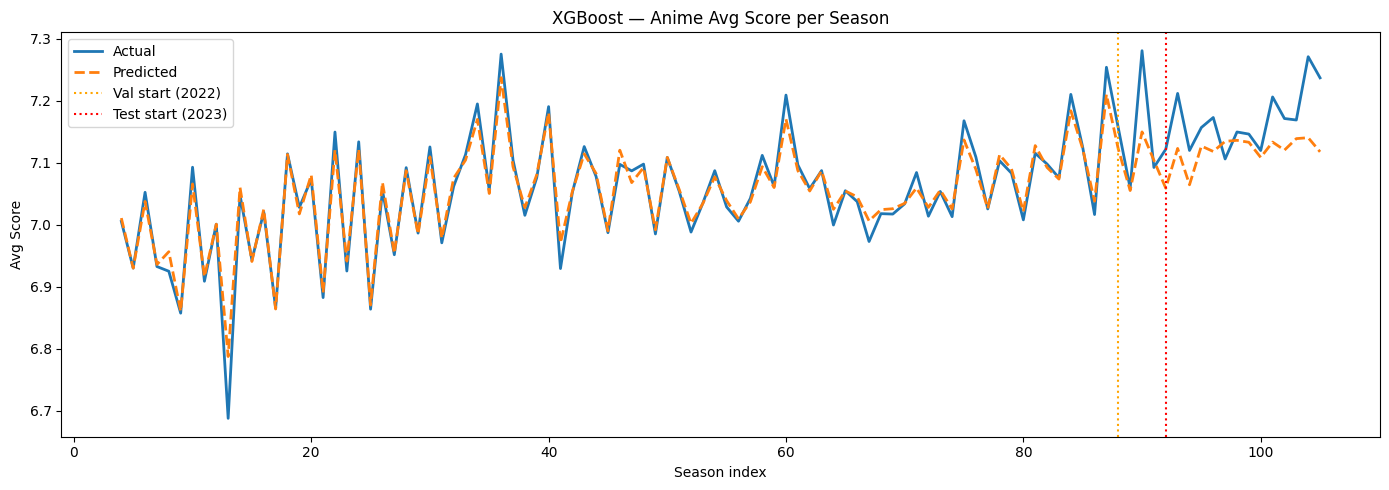

In [ ]:
full_pred = model.predict(df[features])

plt.figure(figsize=(14, 5))
plt.plot(df['season_index'], df[target],  label='Actual',    linewidth=2)
plt.plot(df['season_index'], full_pred,   label='Predicted', linestyle='--', linewidth=2)

val_start  = df[df['year'] == 2022]['season_index'].iloc[0]
test_start = df[df['year'] >= 2023]['season_index'].iloc[0]
plt.axvline(val_start,  color='orange', linestyle=':', label='Val start (2022)')
plt.axvline(test_start, color='red',    linestyle=':', label='Test start (2023)')

plt.xlabel('Season index')
plt.ylabel('Avg Score')
plt.title('XGBoost — Anime Avg Score per Season')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Feature Importance

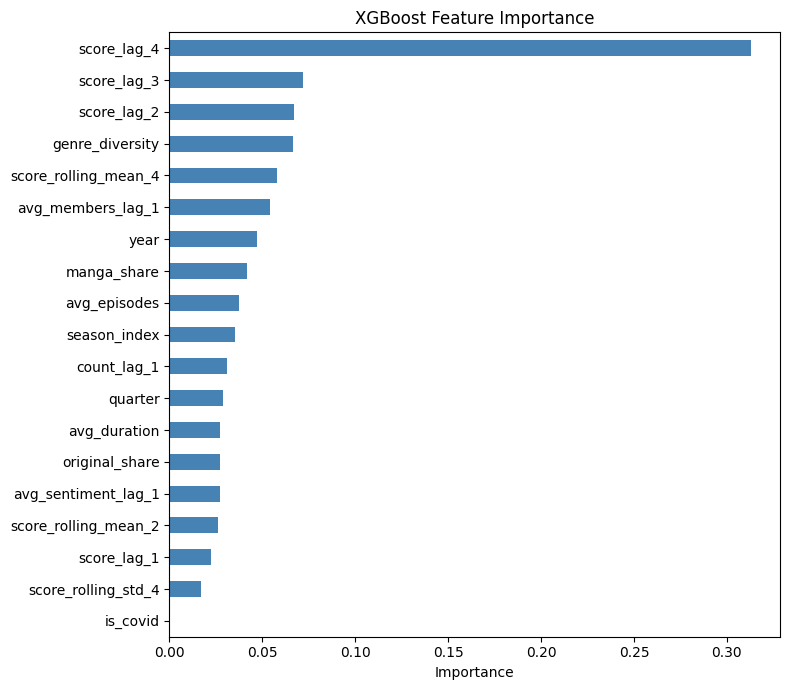

In [12]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 7))
importance.plot(kind='barh', color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()